## Implementing Simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

In [5]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.0,          # deterministic for agents
)

llm.invoke("Hello!")

AIMessage(content="Hello. It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 37, 'total_tokens': 62, 'completion_time': 0.05303987, 'completion_tokens_details': None, 'prompt_time': 0.004222523, 'prompt_tokens_details': None, 'queue_time': 0.048873154, 'total_time': 0.057262393}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c50e7-63a4-7ea1-80c4-96c6ab79032e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 25, 'total_tokens': 62})

## Nodes

In [6]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
def superbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [7]:
graph = StateGraph(State)

# Nodes
graph.add_node("chatbot", superbot)

# Edges
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

In [8]:
graph_builder = graph.compile(checkpointer=memory)

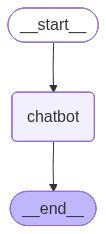

In [9]:
## To Visualize the Graph Image
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [10]:
## Invocation
config = {"configurable": {"thread_id": "4"}}
graph_builder.invoke({'messages': ["Hello, My name is Gowtham."]},config=config)

{'messages': [HumanMessage(content='Hello, My name is Gowtham.', additional_kwargs={}, response_metadata={}, id='17947fcb-f3ca-4754-845f-7c722e0e2bf3'),
  AIMessage(content="Hello Gowtham! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 44, 'total_tokens': 72, 'completion_time': 0.043228535, 'completion_tokens_details': None, 'prompt_time': 0.001941835, 'prompt_tokens_details': None, 'queue_time': 0.048439162, 'total_time': 0.04517037}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c50e7-65df-7762-8450-30822ba39a98-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 28, 'total_tokens': 72})]}

## Streaming the Responses with Stream Method

In [11]:
config = {"configurable": {"thread_id": "6"}}
for event in graph_builder.stream({'messages': ["Hello, My name is Gowtham."]}, stream_mode="updates", config=config):
    print(event)

{'chatbot': {'messages': [AIMessage(content="Hello Gowtham! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 44, 'total_tokens': 72, 'completion_time': 0.05152673, 'completion_tokens_details': None, 'prompt_time': 0.00368379, 'prompt_tokens_details': None, 'queue_time': 0.04940482, 'total_time': 0.05521052}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c50e7-66ae-7ad0-9486-1191f8cc33f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 28, 'total_tokens': 72})]}}


In [12]:
for event in graph_builder.stream({'messages': ["I love sports."]}, stream_mode="values", config=config):
    print(event)

{'messages': [HumanMessage(content='Hello, My name is Gowtham.', additional_kwargs={}, response_metadata={}, id='a71498c9-49e9-4636-9192-01e00f52097a'), AIMessage(content="Hello Gowtham! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 44, 'total_tokens': 72, 'completion_time': 0.05152673, 'completion_tokens_details': None, 'prompt_time': 0.00368379, 'prompt_tokens_details': None, 'queue_time': 0.04940482, 'total_time': 0.05521052}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c50e7-66ae-7ad0-9486-1191f8cc33f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 28, 'total_tokens': 72}), HumanMessage(content='I love sports.', additional_kwargs={}, response_met

In [13]:
for event in graph_builder.stream({'messages': ["I love Cricket."]}, stream_mode="updates", config=config):
    print(event)

{'chatbot': {'messages': [AIMessage(content="Cricket is an amazing sport, Gowtham! It's one of the most popular sports in the world, and it's especially loved in countries like India, Australia, and the UK. Who's your favorite cricketer? Are you a fan of the Indian national team, or do you support a particular IPL team?\n\nAnd do you play cricket yourself, or do you just enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 82, 'prompt_tokens': 152, 'total_tokens': 234, 'completion_time': 0.247535682, 'completion_tokens_details': None, 'prompt_time': 0.008412805, 'prompt_tokens_details': None, 'queue_time': 0.048542044, 'total_time': 0.255948487}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c50e7-688d-7d01-b9a4-f994a4ca3779-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens

In [14]:
for event in graph_builder.stream({'messages': ["I love Football."]}, stream_mode="values", config=config):
    print(event)

{'messages': [HumanMessage(content='Hello, My name is Gowtham.', additional_kwargs={}, response_metadata={}, id='a71498c9-49e9-4636-9192-01e00f52097a'), AIMessage(content="Hello Gowtham! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 44, 'total_tokens': 72, 'completion_time': 0.05152673, 'completion_tokens_details': None, 'prompt_time': 0.00368379, 'prompt_tokens_details': None, 'queue_time': 0.04940482, 'total_time': 0.05521052}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c50e7-66ae-7ad0-9486-1191f8cc33f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 28, 'total_tokens': 72}), HumanMessage(content='I love sports.', additional_kwargs={}, response_met

## Streaming the Responses with astream Method

In [15]:
config = {"configurable": {"thread_id": "10"}}
async for event in graph_builder.astream_events({'messages': ["Hello, My name is Gowtham."]}, config=config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hello, My name is Gowtham.']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019c50e7-6ca7-7312-83d5-b29f10b65e20', 'metadata': {'thread_id': '10'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hello, My name is Gowtham.', additional_kwargs={}, response_metadata={}, id='a81d113d-b24b-43f5-b675-18fde6ad1b72')]}}, 'name': 'chatbot', 'tags': ['graph:step:1'], 'run_id': '019c50e7-6ca9-7c70-a929-a80270671911', 'metadata': {'thread_id': '10', 'langgraph_step': 1, 'langgraph_node': 'chatbot', 'langgraph_triggers': ('branch:to:chatbot',), 'langgraph_path': ('__pregel_pull', 'chatbot'), 'langgraph_checkpoint_ns': 'chatbot:c15d0bc7-ef3d-974a-0001-e7eb5d1805ef'}, 'parent_ids': ['019c50e7-6ca7-7312-83d5-b29f10b65e20']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hello, My name is Gowtham.', additional_kwargs={}, response_metadata={}, id='a81